In [ ]:
import xarray as xr 
import matplotlib.pyplot as plt
import os
import cartopy
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import matplotlib as mpl
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import datetime
import cdsapi
import zipfile 
import pandas as pd

%matplotlib widget

def plot_map(ax,var,lat,lon,title,cmap,vmin=None,vmax=None,norm=None,extend='both',ctitle=None):

    img_extent = (lon[0], lon[-1], lat[0], lat[-1])
    ax.coastlines('50m',color='black',linewidth=0.5)
    ax.add_feature(cfeature.OCEAN,color='lightgrey')
    # ax.add_feature(cfeature.LAND)
    origin='lower' # 'upper'
    if norm is not None:
        im = ax.imshow(var,cmap = cmap,norm=norm,origin=origin,extent=img_extent,interpolation='None') 
    else:
        im = ax.imshow(var,cmap = cmap,vmin=vmin,vmax=vmax,origin=origin,extent=img_extent,interpolation='None') 
    
    # rivers_50m = cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '50m')
    # gl = ax.gridlines(draw_labels=True)
    # gl.xlocator = mticker.FixedLocator(np.arange(-180,190,20))
    # cb = plt.colorbar(im, ax=ax,shrink=0.6,extend=extend,orientation='horizontal',pad=0.1)
    cb = plt.colorbar(im, ax=ax,shrink=0.6,extend=extend,orientation='vertical',pad=0.05)
    cb.ax.tick_params(labelsize=8)
    # if ctitle is not None:
    #     cb.ax.set_title(ctitle,pad=-25)
    # cb.ax.set_title(ctitle)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5,color='black')
    # ax.set_title(title,fontsize=10)
    ax.set_label(ctitle,fontsize=8)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color='black', alpha=0.5, linestyle='--', draw_labels=True)
    gl.bottom_labels = True
    # gl.top_labels = False
    gl.top_labels = False
    gl.left_labels = True
    gl.right_labels=False
    # gl.xlines = True
    gl.xlocator = mticker.FixedLocator(np.arange(-180,200,20))
    gl.ylocator = mticker.FixedLocator(np.arange(-90,110,20))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    return ax

datadir = 'Ozone/MERGED_UV/'

In [ ]:
## Download ozone data from Copernicus Climate Data Store

datazipfile = 'Ozone.zip'
year=[f'{year}' for year in range(2013,2024)]
month= [f'{month:02d}' for month in range(1,13)]
version='v2000'

dataset = "satellite-ozone-v1"
request = {
    "processing_level": "level_3",
    "variable": "atmosphere_mole_content_of_ozone",
    "vertical_aggregation": "total_column",
    "sensor": ["merged_uv"],
    "year": year,
    "month": month,
    "version": f'{version}',
}
target = datazipfile
client = cdsapi.Client()
client.retrieve(dataset, request, target)

with zipfile.ZipFile(datazipfile, "r") as zip_ref: #unzip into datadir directory
    zip_ref.extractall(datadir+'/.')


2025-05-26 12:21:06,288 WARNING [2025-05-26T00:00:00] Service may suffer disruptions. Please check [here](https://status.ecmwf.int/) for status updates.
2025-05-26 12:21:06,289 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-05-26 12:21:06,290 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-05-26 12:21:07,383 INFO Request ID is 5128cf88-2ad5-4b1a-9306-040eb4b9985e
2025-05-26 12:21:07,482 INFO status has been updated to accepted
2025-05-26 12:21:28,580 INFO status has been updated to running
2025-05-26 12:23:01,397 INFO status has been updated to successful


809e8dee2d80e76de0e11f145db3d06f.zip:   0%|          | 0.00/249M [00:00<?, ?B/s]

/perm/cxjo/conda/envs/work/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


TypeError: Artist.set_label() got an unexpected keyword argument 'fontsize'

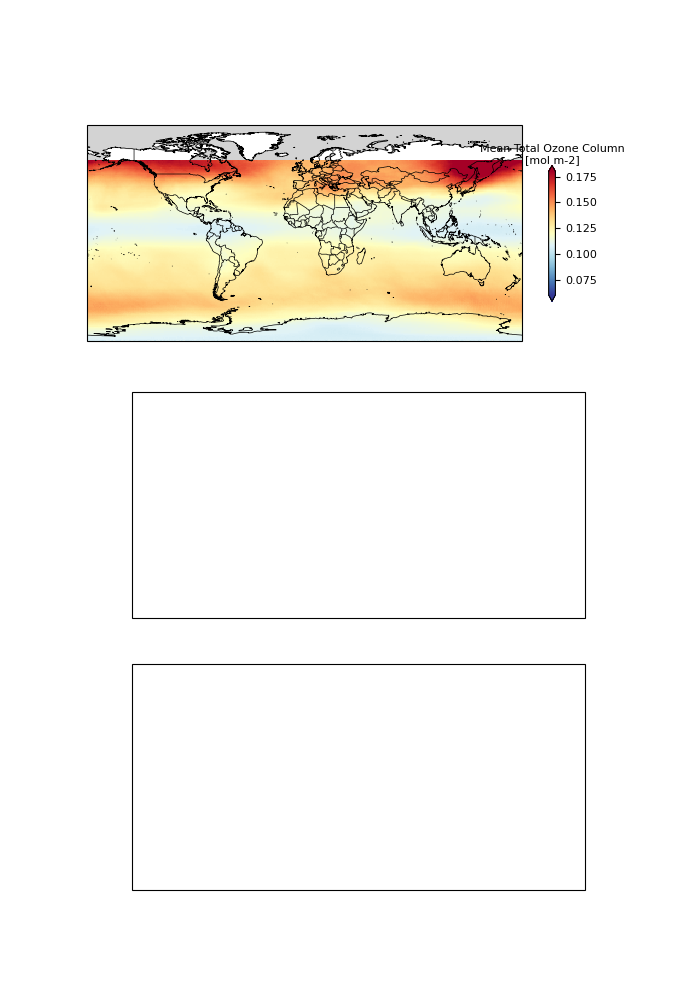

In [74]:
## Open files and plot
# if not os.path.isfile(f'Ozone/{fname}'): os.system(f'wget '+manif_file+fname+' -P Ozone/')
# datadir = 'Ozone/MERGED_UV/'

year=2021
month=12

version = 'v2000'
fname =f'{year}{month:02d}-C3S-L3_OZONE-O3_PRODUCTS-MERGED_UV-MERGED-ALG-MONTHLY-{version}.nc'

nc = xr.open_dataset(datadir+fname)
nc.coords['longitude'] = (nc.coords['longitude'] + 180) % 360 - 180
nc = nc.sortby(nc.longitude)

toc_v20 = nc['total_ozone_column']
lat = nc['latitude'].values
lon = nc['longitude'].values

version = 'v2100'
fname =f'{year}{month:02d}-C3S-L3_OZONE-O3_PRODUCTS-MERGED_UV-MERGED-ALG-MONTHLY-{version}.nc'

nc = xr.open_dataset(datadir+fname)
nc.coords['longitude'] = (nc.coords['longitude'] + 180) % 360 - 180
nc = nc.sortby(nc.longitude)

toc_v21 = nc['total_ozone_column']
# lat = nc['latitude'].values
# lon = nc['longitude'].values

diff = toc_v21 - toc_v20

projection = ccrs.PlateCarree(central_longitude=0)
fig1, axs = plt.subplots(3, 1, figsize=(7, 10), subplot_kw={'projection': projection})

ctitle=f'{toc_v20.long_name}\n[{toc_v20.units}]'

cmap='RdYlBu_r'

# img_extent = (lon[0], lon[-1], lat[0], lat[-1])
# print(img_extent)
# ax1.coastlines('50m',color='black',linewidth=0.5)
# ax1.add_feature(cfeature.OCEAN,color='lightgrey')
# # ax.add_feature(cfeature.LAND)
# origin='lower' # 'upper'
# # im = ax1.imshow(toc,cmap = cmap,norm=False,origin=origin,extent=img_extent,interpolation='None') 
# im = ax1.imshow(toc,extent=img_extent,origin=origin,interpolation='None',cmap=cmap,vmin=0.06,vmax=0.18) 
# plt.show()
title=f'{toc_v20.long_name} v2000\n{year}-{month}'
axs[0] = plot_map(axs[0],toc_v20,nc['latitude'],nc['longitude'],title,cmap=cmap,vmin=0.06,vmax=0.18,norm=None,extend='both',ctitle=ctitle)
title=f'{toc_v21.long_name} v2100\n{year}-{month}'
axs[1] = plot_map(axs[1],toc_v21,nc['latitude'],nc['longitude'],title,cmap=cmap,vmin=0.06,vmax=0.18,norm=None,extend='both',ctitle=ctitle)
title='v2100-v2000'
cmap='RdBu'
axs[2] = plot_map(axs[2],diff,nc['latitude'],nc['longitude'],title,cmap=cmap,norm=None,extend='both',ctitle=ctitle)
plt.tight_layout()
plt.show()

In [47]:
import glob 

version = 'v2000'
fnames =sorted(glob.glob(datadir+f'*{version}.nc'))
dates_v20 = [pd.to_datetime(fname.split('/')[-1].split('-')[0], format="%Y%m") for fname in fnames]
nc = xr.open_mfdataset(fnames,combine='nested', concat_dim='time')
toc_v20 = nc['total_ozone_column']
toc_v20 = toc_v20.assign_coords(time=dates_v20)

version = 'v2100'
fnames =sorted(glob.glob(datadir+f'*{version}.nc'))
dates_v21 = [pd.to_datetime(fname.split('/')[-1].split('-')[0], format="%Y%m") for fname in fnames]

# # nc = xr.open_mfdataset(fnames,combine='nested', concat_dim='time', parallel=True)
nc = xr.open_mfdataset(fnames,combine='nested', concat_dim='time')
toc_v21 = nc['total_ozone_column']
toc_v21 = toc_v21.assign_coords(time=dates_v21)
# print(toc_v21)

toc_v20_mean = toc_v20.mean(dim=['latitude','longitude'])
toc_v21_mean = toc_v21.mean(dim=['latitude','longitude'])

# set missing values to nan
# toc_v21_mean_filled = toc_v21_mean.reindex(time=toc_v20_mean.time)

toc_diff = toc_v21_mean - toc_v20_mean

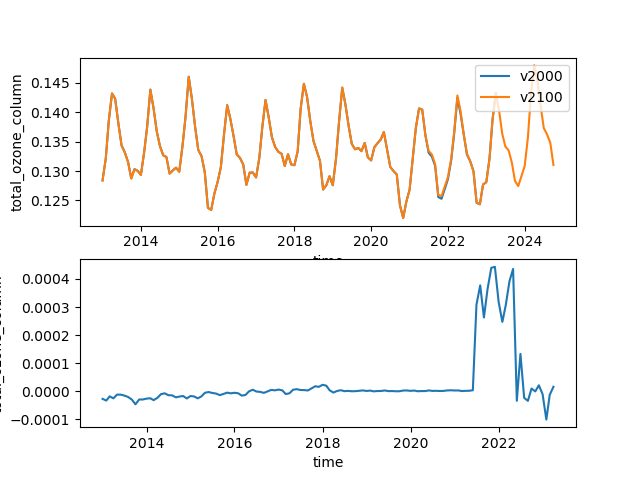

In [49]:

plt.figure()
plt.subplot(2, 1, 1)
toc_v20_mean.plot()
toc_v21_mean.plot()
plt.legend(['v2000','v2100'])
plt.subplot(2, 1, 2)
toc_diff.plot()
plt.show()

<xarray.Dataset> Size: 2MB
Dimensions:                                (Lon: 720, Lat: 361, Time: 1, time: 1)
Coordinates:
    time                                   (Time) datetime64[ns] 8B ...
Dimensions without coordinates: Lon, Lat, Time
Data variables:
    longitude                              (Lon) float32 3kB ...
    latitude                               (Lat) float32 1kB ...
    total_ozone_column                     (time, Lat, Lon) float32 1MB ...
    total_ozone_column_standard_deviation  (time, Lat, Lon) float32 1MB ...
Attributes: (12/19)
    Authors:                  R.J. van der A
    Affiliation:              KNMI (Royal Netherlands Meteorological Institute)
    Email:                    avander@knmi.nl
    Data_created_by:          TM3-DAM (version 3.3) / MSR-2
    Ozone_field_date:         [2023    1]
    Date_format:              year, month
    ...                       ...
    Field_Average_O3_std:     Standard deviation of monthly average ozone column
    Units: 

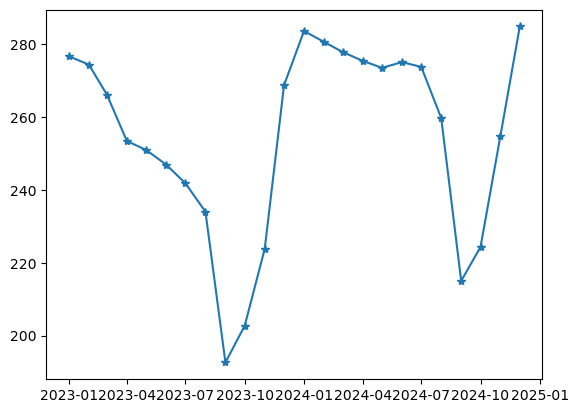

In [53]:
## time series over Antarctica
import pandas as pd

dates = pd.date_range('2023-01-01','2024-12-01',freq='MS')
o3_list=[]
for date in dates:
    year=date.year
    month=date.month
    manif_file=f'https://wdc.dlr.de/C3S_312b_Lot2/O3/TC/ASSIM/MSR/ALG/v0025/L4_MONTHLY/{year}/'
    fname = f'{year}{month:02d}-C3S-L4_OZONE-O3_PRODUCTS-MSR-ASSIM-ALG-MONTHLY-v0025.nc'
    # fname = 'https://wdc.dlr.de/C3S_312b_Lot2/O3/TC/ASSIM/MSR/ALG/v0025/L4_MONTHLY/2024/202401-C3S-L4_OZONE-O3_PRODUCTS-MSR-ASSIM-ALG-MONTHLY-v0025.nc'
    if not os.path.isfile(f'Ozone/{fname}'): os.system(f'wget '+manif_file+fname+' -P Ozone/')
    # https://wdc.dlr.de/C3S_312b_Lot2/O3/TC/ASSIM/MSR/ALG/v0025/L4_MONTHLY/2024/202401-C3S-L4_OZONE-O3_PRODUCTS-MSR-ASSIM-ALG-MONTHLY-v0025.nc
    nc = xr.open_dataset('Ozone/'+fname)
    print(nc)
    print(nc.latitude[60].values)
    # LatIndexer = 'Lat'
    # toc = nc['total_ozone_column'].isel(time=0,Lat=slice(0,60))
    toc = nc['total_ozone_column'].isel(time=0)[0:60,:] #index 60 corresponds to -60
    o3_list.append(toc.mean())
    
plt.figure()
plt.plot(dates,o3_list,'*-') 
plt.show()       